In [34]:
import pandas as pd

df = pd.read_csv("boxing_force_15000.csv")  # if in same folder
print(df.shape)
print(df.head())



(15000, 8)
   side_to_side_peak  up_and_down_peak  forward_and_back_peak  \
0           5.898899          3.813625              23.810378   
1           4.394945          5.508111              20.795525   
2           2.049517          7.371715              15.480016   
3           1.405801          2.886042              13.308993   
4           6.470583          2.722574              19.981500   

   rotation_speed_x_peak  rotation_speed_y_peak  rotation_speed_z_peak  \
0               4.871630               3.608787               9.825160   
1               0.740519               3.981573               5.076857   
2               4.834566               4.024715               4.587004   
3               0.908064               1.574978               3.838440   
4               4.968259               3.522674              12.080941   

   total_energy  impact_force_newtons  
0     89.538181            146.643953  
1    186.277565            118.217782  
2     45.383143             99.56

In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("boxing_force_15000.csv")


X = df[["side_to_side_peak", "up_and_down_peak", "forward_and_back_peak",
        "rotation_speed_x_peak", "rotation_speed_y_peak", 
        "rotation_speed_z_peak", "total_energy"]]
y = df["impact_force_newtons"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("MAE  :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2   :", r2_score(y_test, y_pred))

MAE  : 4.33703472627203
RMSE : 5.463421960643289
R2   : 0.9607996932524985


In [ ]:
import numpy as np


print("Enter punch sensor readings:")
side_to_side = float(input("Side to Side Peak (1.0 - 8.0): "))
up_and_down = float(input("Up and Down Peak (1.0 - 8.0): "))
forward_and_back = float(input("Forward and Back Peak (5.0 - 25.0): "))
rotation_x = float(input("Rotation Speed X Peak (0.5 - 5.0): "))
rotation_y = float(input("Rotation Speed Y Peak (0.5 - 5.0): "))
rotation_z = float(input("Rotation Speed Z Peak (2.0 - 15.0): "))
total_energy = float(input("Total Energy (20 - 200): "))


user_input = np.array([[side_to_side, up_and_down, forward_and_back,
                        rotation_x, rotation_y, rotation_z, total_energy]])


lr_pred = model.predict(user_input)[0]

print(f"\nPredicted Impact Force: {lr_pred:.2f} Newtons")

In [38]:
from sklearn.neighbors import KNeighborsRegressor


knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)


y_pred_knn = knn_model.predict(X_test)


print("MAE  :", mean_absolute_error(y_test, y_pred_knn))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2   :", r2_score(y_test, y_pred_knn))

MAE  : 5.279308543036494
RMSE : 6.677852724533891
R2   : 0.9414356063780398


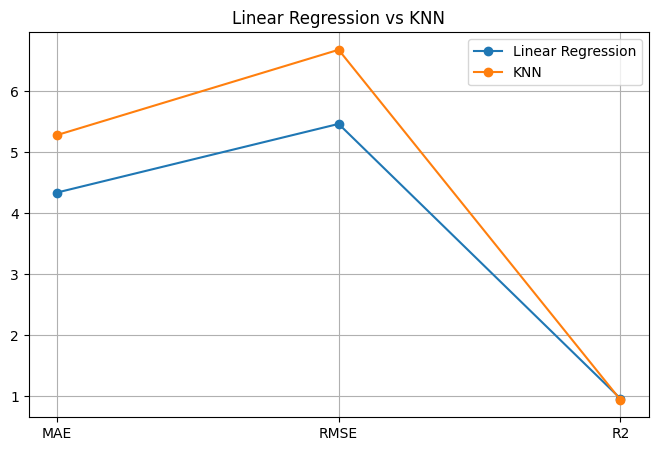

In [40]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R2']
lr_scores = [4.337, 5.463, 0.961]
knn_scores = [5.279, 6.678, 0.941]

plt.figure(figsize=(8, 5))
plt.plot(metrics, lr_scores, marker='o', label='Linear Regression')
plt.plot(metrics, knn_scores, marker='o', label='KNN')

plt.title('Linear Regression vs KNN')
plt.legend()
plt.grid(True)
plt.show()

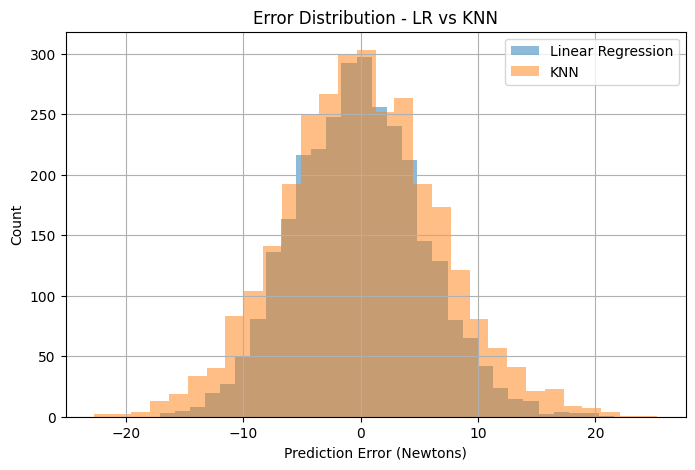

In [42]:
import matplotlib.pyplot as plt

lr_errors = y_test - y_pred
knn_errors = y_test - y_pred_knn

plt.figure(figsize=(8, 5))
plt.hist(lr_errors, bins=30, alpha=0.5, label='Linear Regression')
plt.hist(knn_errors, bins=30, alpha=0.5, label='KNN')

plt.title('Error Distribution - LR vs KNN')
plt.xlabel('Prediction Error (Newtons)')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, label='Linear Regression')
plt.scatter(y_test, y_pred_knn, alpha=0.3, label='KNN')

plt.xlabel('Actual Force')
plt.ylabel('Predicted Force')
plt.title('Actual vs Predicted - LR vs KNN')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("boxing_force_15000.csv")
 
X = df[["side_to_side_peak", "up_and_down_peak", "forward_and_back_peak",
        "rotation_speed_x_peak", "rotation_speed_y_peak", 
        "rotation_speed_z_peak", "total_energy"]]
y = df["impact_force_newtons"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


print("Enter punch sensor readings:")
side_to_side = float(input("Side to Side Peak (1.0 - 8.0): "))
up_and_down = float(input("Up and Down Peak (1.0 - 8.0): "))
forward_and_back = float(input("Forward and Back Peak (5.0 - 25.0): "))
rotation_x = float(input("Rotation Speed X Peak (0.5 - 5.0): "))
rotation_y = float(input("Rotation Speed Y Peak (0.5 - 5.0): "))
rotation_z = float(input("Rotation Speed Z Peak (2.0 - 15.0): "))
total_energy = float(input("Total Energy (20 - 200): "))

# Prepare Input
user_input = np.array([[side_to_side, up_and_down, forward_and_back,
                        rotation_x, rotation_y, rotation_z, total_energy]])

# Predict
lr_pred = model.predict(user_input)[0]

print(f"\nPredicted Impact Force: {lr_pred:.2f} Newtons")

In [8]:
import numpy as np
import pandas as pd

n = 15000

data = pd.DataFrame({
    "age": np.random.randint(18, 60, n),
    "weight": np.random.randint(50, 100, n),
    "steps": np.random.randint(0, 20000, n),
    "calories": np.random.randint(1500, 4000, n),
    "activity_level": np.random.choice([1,2,3], n),  # low, medium, high
})

# Generate heart rate based on realistic relation
data["heart_rate"] = (
    60
    + (data["activity_level"] * 20)
    + (data["steps"] / 1000)
    - (data["age"] * 0.2)
    + np.random.normal(0, 5, n)
)

print(data.head())

   age  weight  steps  calories  activity_level  heart_rate
0   20      95   2284      2504               2  104.440118
1   51      86  19935      1939               2  111.112531
2   20      71  18398      3359               2  120.333113
3   43      85  10305      3696               3  116.168789
4   49      62  16376      2464               1   93.369268


In [10]:
import numpy as np
import pandas as pd

# --- CREATE DATASET ---
n = 15000

data = pd.DataFrame({
    "age": np.random.randint(18, 60, n),
    "weight": np.random.randint(50, 100, n),
    "steps": np.random.randint(0, 20000, n),
    "calories": np.random.randint(1500, 4000, n),
    "activity_level": np.random.choice([1,2,3], n),
})

data["heart_rate"] = (
    60
    + (data["activity_level"] * 20)
    + (data["steps"] / 1000)
    - (data["age"] * 0.2)
    + np.random.normal(0, 5, n)
)

# --- SPLIT DATA ---
from sklearn.model_selection import train_test_split

X = data.drop("heart_rate", axis=1)
y = data["heart_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# --- TRAIN MODEL ---
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# --- CHECK ACCURACY ---
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9251273366564969


In [ ]:
# --- TAKE USER INPUT ---
print("\nEnter your details:")

age = float(input("Age (18-60): "))
weight = float(input("Weight (50-100 kg): "))
steps = float(input("Steps (0-20000): "))
calories = float(input("Calories (1500-4000): "))
activity = int(input("Activity Level (1=Low, 2=Medium, 3=High): "))

# --- PREPARE INPUT ---
user_data = np.array([[age, weight, steps, calories, activity]])

# --- PREDICT ---
predicted_hr = model.predict(user_data)[0]

print(f"\nPredicted Heart Rate: {predicted_hr:.2f} BPM")

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("fuel_tracker_15000.csv")

X = df[["age", "weight", "steps", "activity_level", "workout_minutes"]]
y = df["calories_burned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Enter your fitness details:")
age             = float(input("Age (18 - 59): "))
weight          = float(input("Weight in kg (50 - 99): "))
steps           = float(input("Steps (0 - 15000): "))
activity_level  = float(input("Activity Level (1 = low, 2 = moderate, 3 = high): "))
workout_minutes = float(input("Workout Minutes (0 - 119): "))

# Prepare input
user_input = np.array([[age, weight, steps, activity_level, workout_minutes]])

# Predict
prediction = model.predict(user_input)[0]

print(f"\nPredicted Calories Burned: {prediction:.2f} calories")

Enter your fitness details:

Predicted Calories Burned: 2270.57 calories


/Users/sakshamlucky72gmail.com/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
